<a href="https://colab.research.google.com/github/sathushetty7/Bank-fraud-detection-ml/blob/main/bank_fraud_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
#hello
# Install the kaggle library
!pip install kaggle

In [9]:
#Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
# The dataset 'mlg-ulb/creditcardfraud' contains a file named 'creditcard.csv'
file_path = "creditcard.csv"

# Load the latest version using the recommended function
df = kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "mlg-ulb/creditcardfraud",
  file_path,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documentation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

print("First 5 records:", df.head())

Using Colab cache for faster access to the 'creditcardfraud' dataset.
First 5 records:    Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ...

In [11]:
df

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0


In [12]:
# DATASET INFO
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [13]:
# STATISTICAL SUMMARY
display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
Time,284807.0,9.481386e+04,47488.145955,0.000000,54201.500000,84692.000000,139320.500000,172792.000000
V1,284807.0,1.168375e-15,1.958696,-56.407510,-0.920373,0.018109,1.315642,2.454930
V2,284807.0,3.416908e-16,1.651309,-72.715728,-0.598550,0.065486,0.803724,22.057729
V3,284807.0,-1.379537e-15,1.516255,-48.325589,-0.890365,0.179846,1.027196,9.382558
V4,284807.0,2.074095e-15,1.415869,-5.683171,-0.848640,-0.019847,0.743341,16.875344
V5,284807.0,9.604066e-16,1.380247,-113.743307,-0.691597,-0.054336,0.611926,34.801666
V6,284807.0,1.487313e-15,1.332271,-26.160506,-0.768296,-0.274187,0.398565,73.301626
V7,284807.0,-5.556467e-16,1.237094,-43.557242,-0.554076,0.040103,0.570436,120.589494
V8,284807.0,1.213481e-16,1.194353,-73.216718,-0.208630,0.022358,0.327346,20.007208
V9,284807.0,-2.406331e-15,1.098632,-13.434066,-0.643098,-0.051429,0.597139,15.594995


In [14]:
#data cleaning


# Missing Values

missing = df.isnull().sum()

display(
    missing[missing > 0].sort_values(ascending=False)
)

if missing.sum() == 0:
    print("No missing values found.")


# Duplicate Rows

duplicates = df.duplicated().sum()

print(f"Duplicate rows: {duplicates:,}")

,0


No missing values found.
Duplicate rows: 1,081


In [15]:
# Target Distribution

class_counts = df["Class"].value_counts()

legitimate = class_counts.get(0, 0)
fraud = class_counts.get(1, 0)
total = len(df)

fraud_percentage = (fraud / total) * 100

print(f"Total transactions     : {total:,}")
print(f"Legitimate transactions: {legitimate:,}")
print(f"Fraudulent transactions: {fraud:,}")
print(f"Fraud percentage       : {fraud_percentage:.4f}%")

Total transactions     : 284,807
Legitimate transactions: 284,315
Fraudulent transactions: 492
Fraud percentage       : 0.1727%


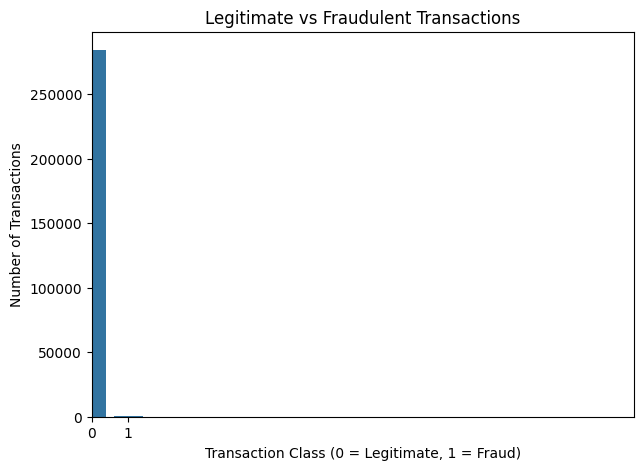

In [16]:
# Fraud Distribution Plot

plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="Class"
)

plt.title("Legitimate vs Fraudulent Transactions")
plt.xlabel("Transaction Class (0 = Legitimate, 1 = Fraud)")
plt.ylabel("Number of Transactions")
plt.xlim(0, 15)
plt.show()



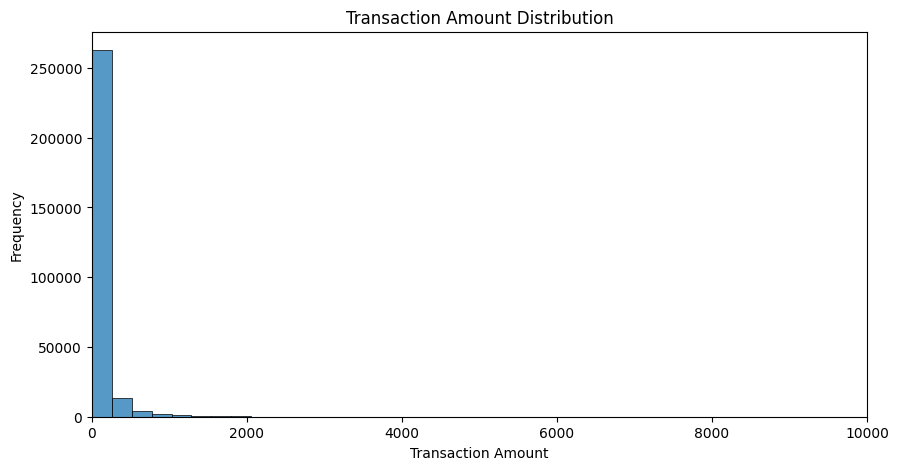

In [17]:
# Transaction Amount

plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x="Amount",
    bins=100
)

plt.title("Transaction Amount Distribution")
plt.xlabel("Transaction Amount")
plt.ylabel("Frequency")
plt.xlim(0, 10000)
plt.show()





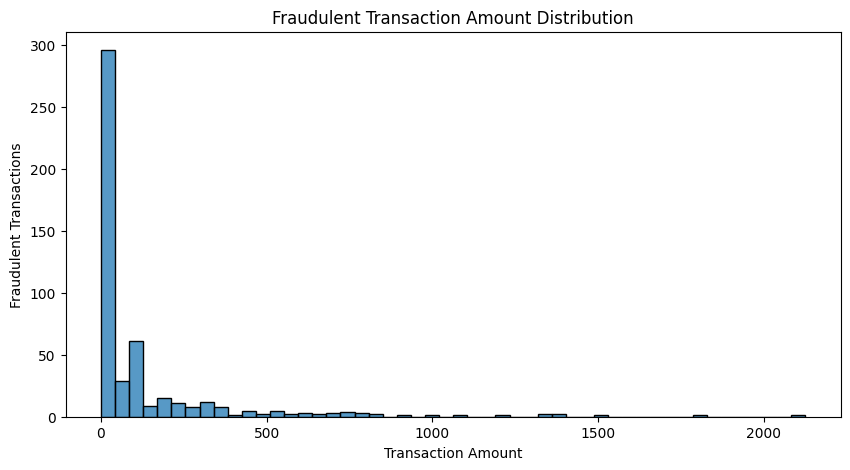

In [18]:
# Fraud Amount Distribution

plt.figure(figsize=(10, 5))

sns.histplot(
    data=df[df["Class"] == 1],
    x="Amount",
    bins=50
)

plt.title("Fraudulent Transaction Amount Distribution")
plt.xlabel("Transaction Amount")
plt.ylabel("Fraudulent Transactions")

plt.show()



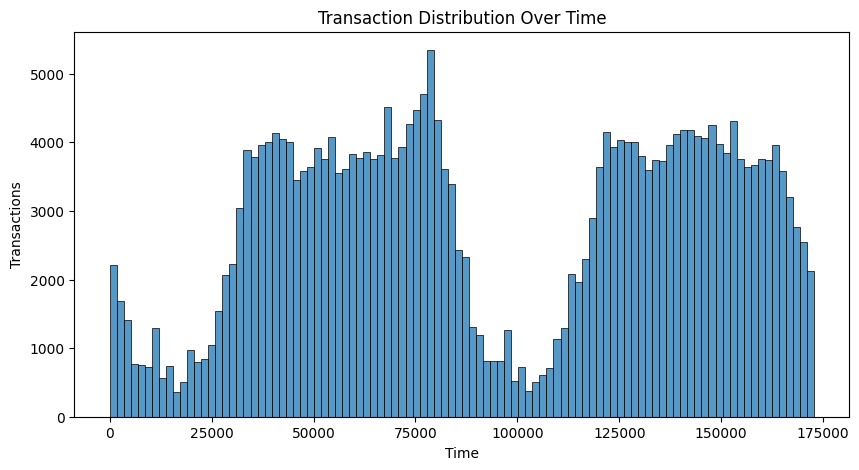

In [19]:
# Time Distribution

plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x="Time",
    bins=100
)

plt.title("Transaction Distribution Over Time")
plt.xlabel("Time")
plt.ylabel("Transactions")

plt.show()




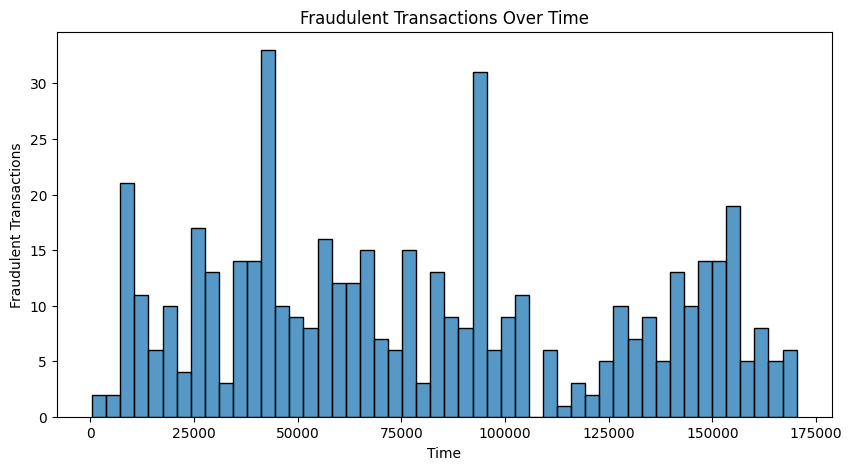

In [20]:
# Fraud Over Time

plt.figure(figsize=(10, 5))

sns.histplot(
    data=df[df["Class"] == 1],
    x="Time",
    bins=50
)

plt.title("Fraudulent Transactions Over Time")
plt.xlabel("Time")
plt.ylabel("Fraudulent Transactions")

plt.show()

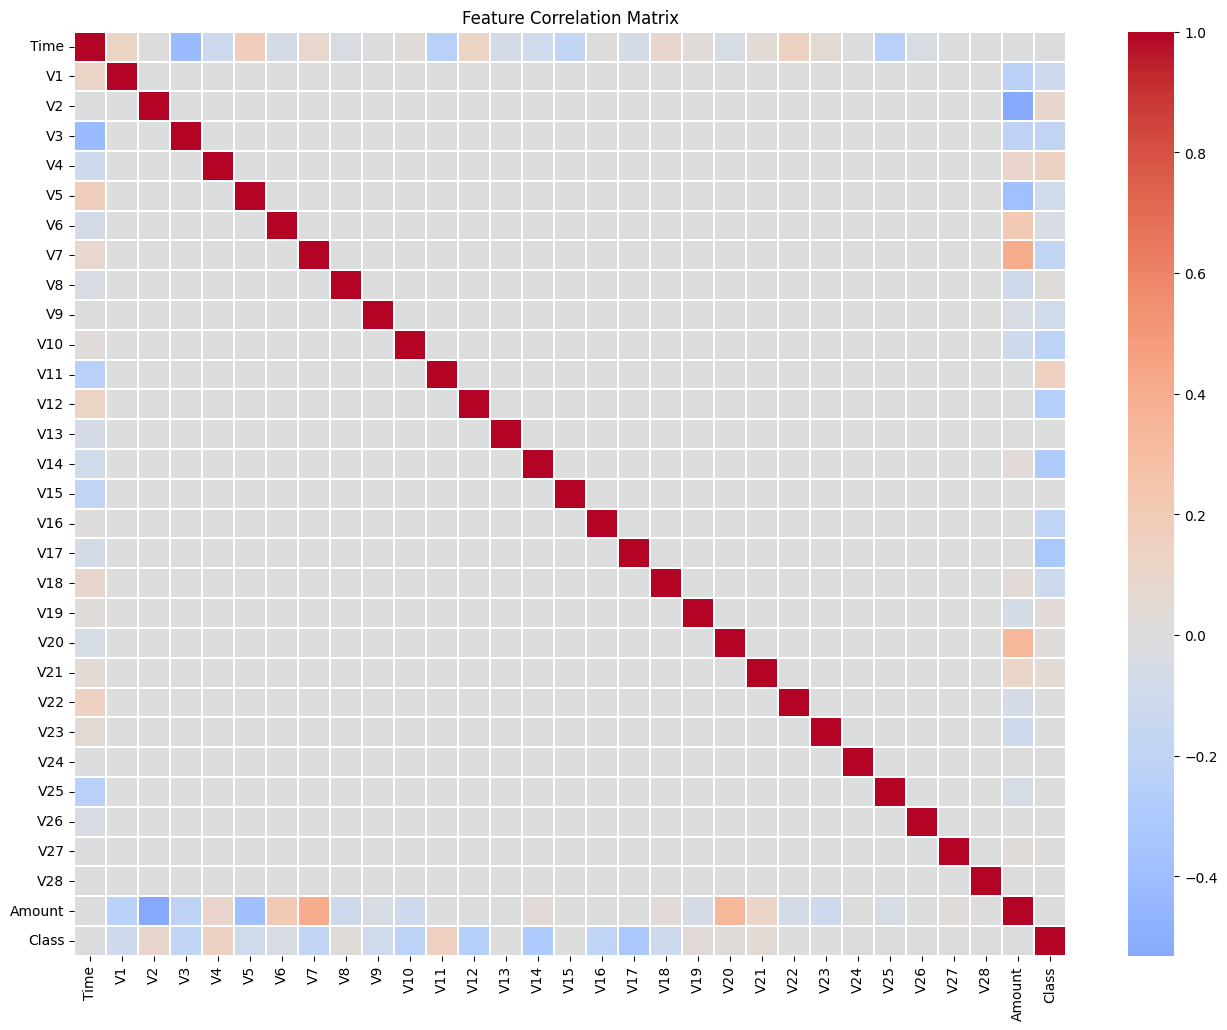

In [21]:
#  Correlation Matrix

plt.figure(figsize=(16, 12))

correlation = df.corr(numeric_only=True)

sns.heatmap(
    correlation,
    cmap="coolwarm",
    center=0,
    linewidths=0.1
)

plt.title("Feature Correlation Matrix")

plt.show()


In [22]:
#  Correlation With Fraud

fraud_correlation = (
    correlation["Class"]
    .sort_values(ascending=False)
)

display(fraud_correlation.to_frame(name="Correlation"))



,Correlation
Class,1.000000
V11,0.154876
V4,0.133447
V2,0.091289
V21,0.040413
V19,0.034783
V20,0.020090
V8,0.019875
V27,0.017580
V28,0.009536


In [23]:
# Fraud vs Legitimate Amount

amount_stats = df.groupby("Class")["Amount"].agg(
    ["count", "mean", "median", "min", "max"]
)

amount_stats.index = [
    "Legitimate",
    "Fraud"
]

display(amount_stats)


,count,mean,median,min,max
Legitimate,284315,88.291022,22.00,0.0,25691.16
Fraud,492,122.211321,9.25,0.0,2125.87


In [24]:

# Final Dataset Summary

print(f"Total transactions : {total:,}")
print(f"Legitimate         : {legitimate:,}")
print(f"Fraud              : {fraud:,}")
print(f"Fraud percentage   : {fraud_percentage:.4f}%")
print(f"Missing values     : {df.isnull().sum().sum():,}")
print(f"Duplicate rows     : {duplicates:,}")
print("========================================")

Total transactions : 284,807
Legitimate         : 284,315
Fraud              : 492
Fraud percentage   : 0.1727%
Missing values     : 0
Duplicate rows     : 1,081


In [25]:

# DATA PREPARATION + FEATURE ENGINEERING

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np

# Create a copy of the dataset


data = df.copy()

print("Dataset shape:", data.shape)



# Separate features (X) and target (y)

X = data.drop("Class", axis=1)
y = data["Class"]

print("\nFeatures shape:", X.shape)
print("Target shape:", y.shape)



# Scale Time and Amount
# V1-V28 are already PCA-transformed.
# Time and Amount are on different scales, so we standardize them.

scaler = StandardScaler()

X[["Time", "Amount"]] = scaler.fit_transform(
    X[["Time", "Amount"]]
)

print("\nTime and Amount have been standardized.")


# Train/Test Split

# stratify=y keeps the fraud/legitimate ratio similar
# in both training and testing datasets.

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)



# Check the resulting shapes


print("\n===== DATA SPLIT =====")

print("Training features :", X_train.shape)
print("Testing features  :", X_test.shape)
print("Training target   :", y_train.shape)
print("Testing target    :", y_test.shape)



#  Check fraud distribution


train_counts = y_train.value_counts()

print("Legitimate:", train_counts[0])
print("Fraud     :", train_counts[1])
print("Fraud %   :", round((train_counts[1] / len(y_train)) * 100, 4))




test_counts = y_test.value_counts()

print("Legitimate:", test_counts[0])
print("Fraud     :", test_counts[1])
print("Fraud %   :", round((test_counts[1] / len(y_test)) * 100, 4))



#  Verify no missing values



print("X_train:", X_train.isnull().sum().sum())
print("X_test :", X_test.isnull().sum().sum())



# Verify target values

print("Training:", sorted(y_train.unique()))
print("Testing :", sorted(y_test.unique()))



# Final summary




print("✓ Features and target separated")
print("✓ Time and Amount standardized")
print("✓ Stratified train/test split completed")
print("✓ Fraud distribution verified")
print("✓ Missing values checked")
print("✓ Data is ready for model training")

Dataset shape: (284807, 31)

Features shape: (284807, 30)
Target shape: (284807,)

Time and Amount have been standardized.

===== DATA SPLIT =====
Training features : (227845, 30)
Testing features  : (56962, 30)
Training target   : (227845,)
Testing target    : (56962,)
Legitimate: 227451
Fraud     : 394
Fraud %   : 0.1729
Legitimate: 56864
Fraud     : 98
Fraud %   : 0.172
X_train: 0
X_test : 0
Training: [np.int64(0), np.int64(1)]
Testing : [np.int64(0), np.int64(1)]
✓ Features and target separated
✓ Time and Amount standardized
✓ Stratified train/test split completed
✓ Fraud distribution verified
✓ Missing values checked
✓ Data is ready for model training



Logistic Regression
----------------------------------------
Accuracy  : 0.9992
Precision : 0.8289
Recall    : 0.6429
F1        : 0.7241
ROC-AUC   : 0.9573
PR-AUC    : 0.7439


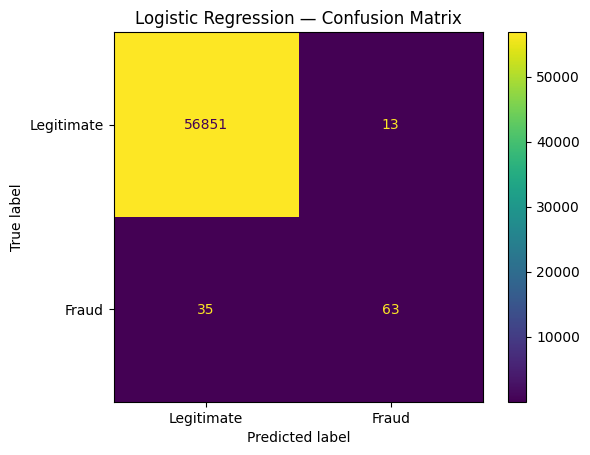


Random Forest
----------------------------------------
Accuracy  : 0.9996
Precision : 0.9412
Recall    : 0.8163
F1        : 0.8743
ROC-AUC   : 0.9630
PR-AUC    : 0.8734


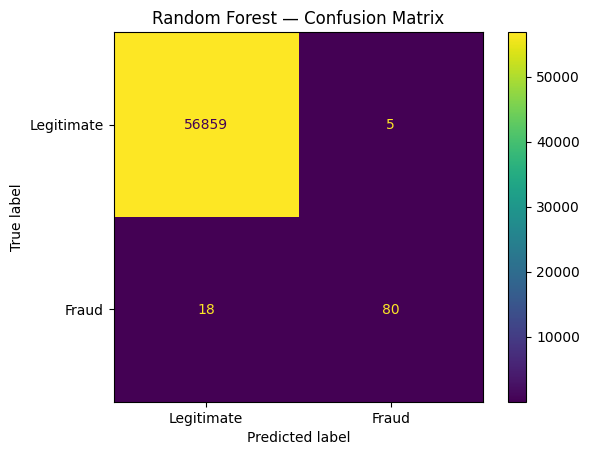


===== BASELINE MODEL COMPARISON =====


,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Logistic Regression,0.9992,0.8289,0.6429,0.7241,0.9573,0.7439
1,Random Forest,0.9996,0.9412,0.8163,0.8743,0.9630,0.8734


In [26]:

# BASELINE MODELS
# Logistic Regression + Random Forest



from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)
import pandas as pd
import matplotlib.pyplot as plt



# Evaluation function


def evaluate_model(model, name):

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    results = {
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1": f1_score(y_test, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, y_prob),
        "PR-AUC": average_precision_score(y_test, y_prob)
    }

    print(f"\n{name}")
    print("-" * 40)

    for metric, value in results.items():
        if metric != "Model":
            print(f"{metric:<10}: {value:.4f}")

    cm = confusion_matrix(y_test, y_pred)

    ConfusionMatrixDisplay(
        cm,
        display_labels=["Legitimate", "Fraud"]
    ).plot()

    plt.title(f"{name} — Confusion Matrix")
    plt.show()

    return results


# Logistic Regression


logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_results = evaluate_model(
    logistic_model,
    "Logistic Regression"
)



# Random Forest

random_forest_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

random_forest_results = evaluate_model(
    random_forest_model,
    "Random Forest"
)



#  Compare models

baseline_results = pd.DataFrame([
    logistic_results,
    random_forest_results
])

print("\n===== BASELINE MODEL COMPARISON =====")

display(
    baseline_results.style.format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1": "{:.4f}",
        "ROC-AUC": "{:.4f}",
        "PR-AUC": "{:.4f}"
    })
)

In [27]:
#  IMBALANCE HANDLING + XGBOOST

from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import pandas as pd
import matplotlib.pyplot as plt

## Imbalance Handling with SMOTE

In [28]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print("Original training target distribution:")
print(y_train.value_counts())
print("\nResampled training target distribution (SMOTE):")
print(y_train_resampled.value_counts())


Original training target distribution:
Class
0    227451
1       394
Name: count, dtype: int64

Resampled training target distribution (SMOTE):
Class
0    227451
1    227451
Name: count, dtype: int64


## XGBoost Model

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [04:59:18] WARNING: /__w/xgboost/xgboost/src/learner.cc:794: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



XGBoost (SMOTE)
----------------------------------------
Accuracy  : 0.9995
Precision : 0.8966
Recall    : 0.7959
F1        : 0.8432
ROC-AUC   : 0.9219
PR-AUC    : 0.7813


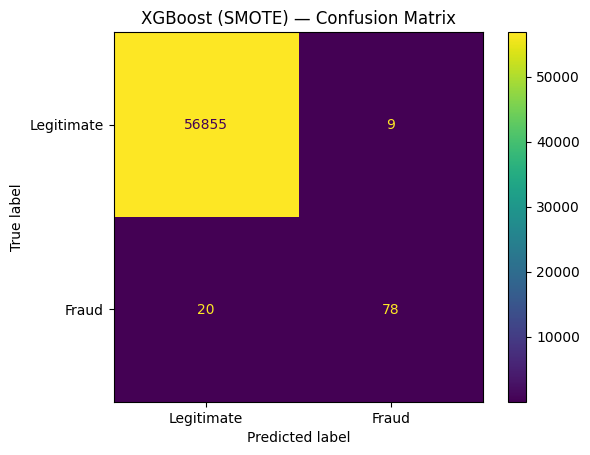

In [29]:
from xgboost import XGBClassifier
xgb_model = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    use_label_encoder=False, # Suppress warning for deprecated parameter
    random_state=42,
    n_jobs=-1
)

xgb_results = evaluate_model(
    xgb_model,
    "XGBoost (SMOTE)"
)


## Final Model Comparison

In [31]:
import pandas as pd

final_results = pd.DataFrame([
    logistic_results,
    random_forest_results,
    xgb_results
])

print("\n===== FINAL MODEL COMPARISON ====")

display(
    final_results.style.format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1": "{:.4f}",
        "ROC-AUC": "{:.4f}",
        "PR-AUC": "{:.4f}"
    })
)



===== FINAL MODEL COMPARISON ====


,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Logistic Regression,0.9992,0.8289,0.6429,0.7241,0.9573,0.7439
1,Random Forest,0.9996,0.9412,0.8163,0.8743,0.9630,0.8734
2,XGBoost (SMOTE),0.9995,0.8966,0.7959,0.8432,0.9219,0.7813


## Final Model Comparison